In [60]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

LABEL_NAMES = ["Normal", "Benign", "Malignant"]
NUM_CLASSES = 3
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4

Using device: cpu


In [62]:
def load_labels(path):
    labels = {}
    with open(path) as f:
        for line in f:
            img, lbl = line.strip().split(',')
            labels[img] = int(lbl)
    return labels

with open("bbox_annot.json") as f:
    bbox_data = json.load(f)

train_labels = load_labels("train.txt")
test_labels = load_labels("test.txt")

print("Train samples:", len(train_labels))
print("Test samples:", len(test_labels))

Train samples: 1133
Test samples: 122


In [63]:
class GallbladderDataset(Dataset):
    def __init__(self, labels_dict, bbox_data, img_dir, transform=None):
        self.items = []
        self.bbox_data = bbox_data
        self.img_dir = img_dir
        self.transform = transform

        for img_name, lbl in labels_dict.items():
            if img_name not in bbox_data:
                continue

            img_path = os.path.join(img_dir, img_name)
            if not os.path.exists(img_path):
                continue

            self.items.append((img_name, lbl))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_name, label = self.items[idx]
        img_path = os.path.join(self.img_dir, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        bbox = self.bbox_data[img_name]["bbs"][0][1]
        x1, y1, x2, y2 = bbox

        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)

        roi = img[y1:y2, x1:x2]

        if roi.size == 0:
            roi = img

        roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))

        if self.transform:
            roi = self.transform(roi)

        return roi, label

In [64]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [65]:
train_dataset = GallbladderDataset(train_labels, bbox_data, "imgs", transform=train_transform)
test_dataset = GallbladderDataset(test_labels, bbox_data, "imgs", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 1133
Test dataset size: 122


In [66]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)

model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [67]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [68]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

In [69]:
def evaluate_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [70]:
train_losses = []

for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f}")

Epoch 1/50 - Loss: 0.4839
Epoch 2/50 - Loss: 0.3388
Epoch 3/50 - Loss: 0.2996
Epoch 4/50 - Loss: 0.2690
Epoch 5/50 - Loss: 0.2572
Epoch 6/50 - Loss: 0.2159
Epoch 7/50 - Loss: 0.1438
Epoch 8/50 - Loss: 0.1706
Epoch 9/50 - Loss: 0.1652
Epoch 10/50 - Loss: 0.1121
Epoch 11/50 - Loss: 0.1180
Epoch 12/50 - Loss: 0.1041
Epoch 13/50 - Loss: 0.0801
Epoch 14/50 - Loss: 0.0481
Epoch 15/50 - Loss: 0.0648
Epoch 16/50 - Loss: 0.0718
Epoch 17/50 - Loss: 0.0500
Epoch 18/50 - Loss: 0.0646
Epoch 19/50 - Loss: 0.0469
Epoch 20/50 - Loss: 0.0809
Epoch 21/50 - Loss: 0.0755
Epoch 22/50 - Loss: 0.0620
Epoch 23/50 - Loss: 0.0522
Epoch 24/50 - Loss: 0.0385
Epoch 25/50 - Loss: 0.0244
Epoch 26/50 - Loss: 0.0179
Epoch 27/50 - Loss: 0.0247
Epoch 28/50 - Loss: 0.0173
Epoch 29/50 - Loss: 0.0120
Epoch 30/50 - Loss: 0.0121
Epoch 31/50 - Loss: 0.0178
Epoch 32/50 - Loss: 0.0142
Epoch 33/50 - Loss: 0.0096
Epoch 34/50 - Loss: 0.0179
Epoch 35/50 - Loss: 0.0222
Epoch 36/50 - Loss: 0.0759
Epoch 37/50 - Loss: 0.0508
Epoch 38/5

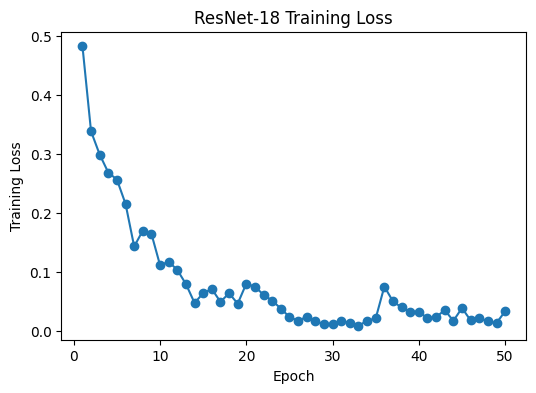

In [76]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("ResNet-18 Training Loss")
plt.show()

In [77]:
y_test, preds, probs = evaluate_model(model, test_loader, device)

acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average="macro", zero_division=0)
rec = recall_score(y_test, preds, average="macro", zero_division=0)
f1 = f1_score(y_test, preds, average="macro", zero_division=0)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=LABEL_NAMES, zero_division=0))

Accuracy: 0.7131147540983607
Precision: 0.7318769818769818
Recall: 0.7403628117913833
F1 Score: 0.7348312758491039

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97        31
      Benign       0.63      0.67      0.65        49
   Malignant       0.62      0.55      0.58        42

    accuracy                           0.71       122
   macro avg       0.73      0.74      0.73       122
weighted avg       0.71      0.71      0.71       122



<Figure size 600x500 with 0 Axes>

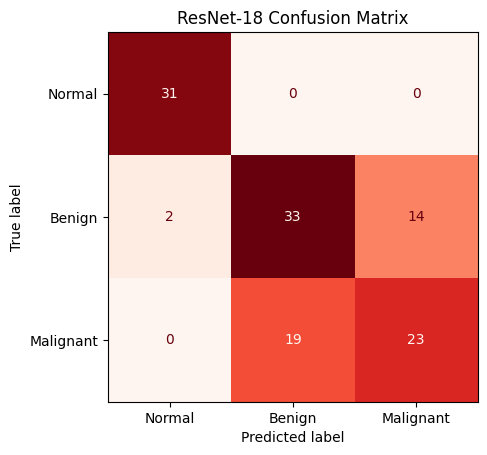

In [79]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)

plt.figure(figsize=(6, 5))
disp.plot(cmap="Reds", colorbar=False)
plt.title("ResNet-18 Confusion Matrix")
plt.show()

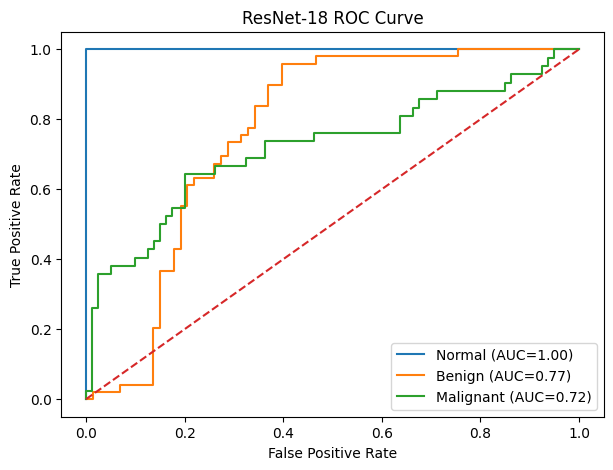

In [80]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(7, 5))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{LABEL_NAMES[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet-18 ROC Curve")
plt.legend()
plt.show()

In [81]:
results_df = pd.DataFrame([{
    "Model": "ResNet-18",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1
}])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,ResNet-18,0.713115,0.731877,0.740363,0.734831
